In [2]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt

from src.d_CSL import *

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [3]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

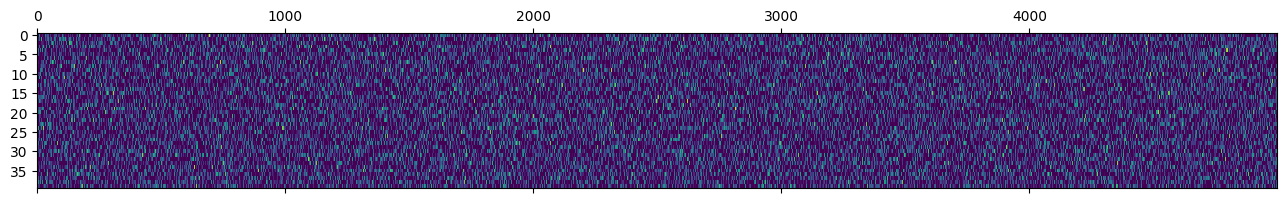

In [4]:
A = np.load('data/Lorenz96/GCp40.npy')
X = np.load('data/Lorenz96/lorenzp40f40_.npy')
X = X.T
plt.matshow(X, aspect='auto',vmin=0)

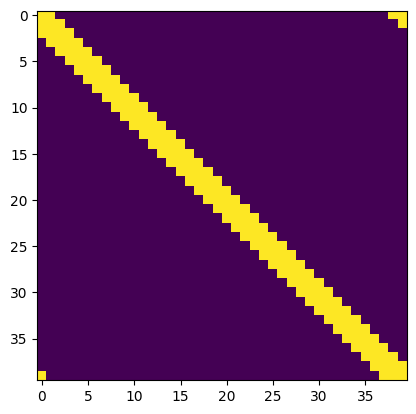

In [5]:
plt.imshow(A!=0)

### Analysis

In [6]:
n_neur,n_perm,N_PASTS = X.shape[0],1000,list(range(1, 3)) 
alpha, beta = 0, 0

### With c-GC* algorithm

In [6]:
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
metrics_fgc = []
# for a, n in enumerate(N_PASTS):
for a in range(10):
    print(f'{a}')
    gcstar = GcStar(n_perm = 1000,
                n_pasts = 2,
                n_lags = 1,
                temporal = True,
                method = 'fcgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)
    infs_fgc.append(inf)
    conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A, simulation=False))
    metrics_fgc.append(np.round(gcstar.all_metrics(),4))
    shds_fgc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=False),4))
print('')

0
1
2
3
4
5
6
7
8
9



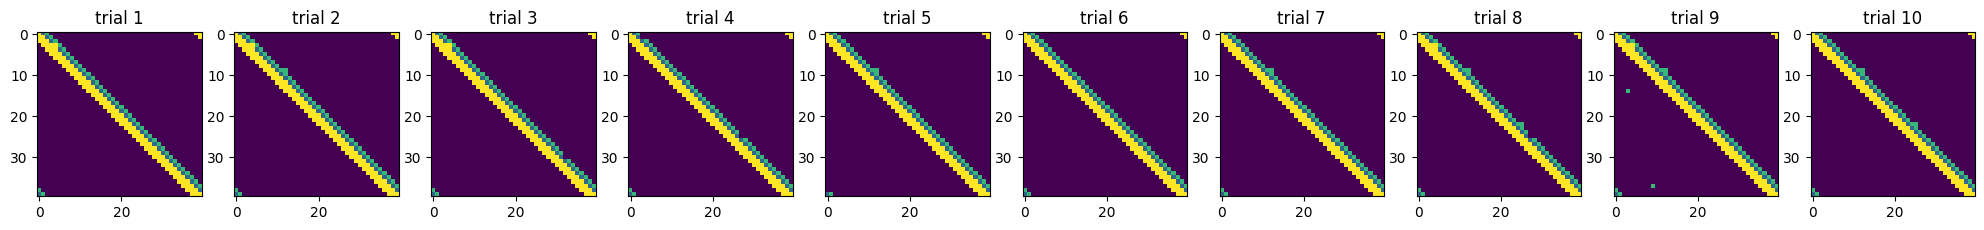

In [7]:
fig, axes = plt.subplots(1,len(infs_fgc), figsize=(2.5*len(infs_fgc),3)) 
for i, ax in enumerate(axes):
    ax.imshow(compare_with_GT(A, infs_fgc[i], simulation=False))
    ax.set_title(f'trial {i+1}')

In [8]:
print(np.round(metrics_fgc, 4))
print('')
print('')
print(f"SHDs are {shds_fgc}")

[[0.9506 0.7516 0.7562 0.0278 0.8642 0.7539]
 [0.95   0.7469 0.7562 0.0285 0.8639 0.7516]
 [0.9512 0.7562 0.7562 0.0271 0.8646 0.7562]
 [0.9512 0.7595 0.75   0.0264 0.8618 0.7547]
 [0.95   0.75   0.75   0.0278 0.8611 0.75  ]
 [0.95   0.75   0.75   0.0278 0.8611 0.75  ]
 [0.9494 0.7453 0.75   0.0285 0.8608 0.7477]
 [0.95   0.7469 0.7562 0.0285 0.8639 0.7516]
 [0.9488 0.7378 0.7562 0.0299 0.8632 0.7469]
 [0.9488 0.7407 0.75   0.0292 0.8604 0.7453]]


SHDs are [np.float64(80.0), np.float64(80.0068), np.float64(79.8197), np.float64(79.6543), np.float64(79.829), np.float64(80.0), np.float64(80.0068), np.float64(79.853), np.float64(80.0271), np.float64(80.0221)]


In [9]:
print(np.mean(metrics_fgc, axis=0))
np.round(np.std(metrics_fgc, axis=0),4)

[0.95    0.74849 0.7531  0.02815 0.8625  0.75079]


array([0.0008, 0.0062, 0.0031, 0.001 , 0.0015, 0.0033])

## c-GC Adaptation

In [7]:
infs_gc = []
conf_mtx_gc = []
shds_gc = []
metrics_gc = []
# for a, n in enumerate(N_PASTS):
for a in range(5):
    print(f'{a}')
    gcstar = GcStar(n_perm = 1000,
                n_pasts = 3,
                n_lags = 1,
                temporal = True,
                method = 'cgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)
    infs_gc.append(inf)
    conf_mtx_gc.append(gcstar.compute_confusion_matrix(A, simulation=False))
    metrics_gc.append(np.round(gcstar.all_metrics(),4))
    shds_gc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=False),4))

0
1
2
3
4


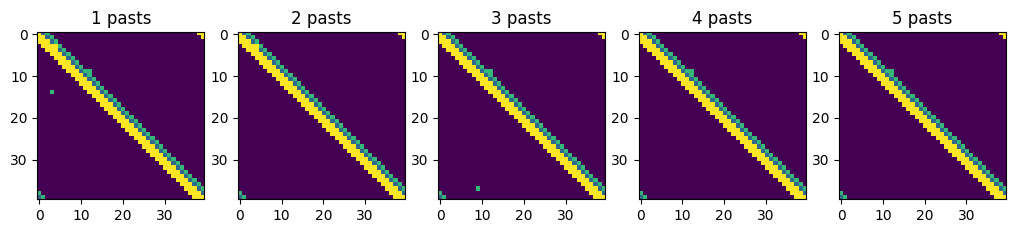

In [8]:
fig, axes = plt.subplots(1,len(infs_gc), figsize=(2.5*len(infs_gc),3))
for i, ax in enumerate(axes):
    ax.imshow(compare_with_GT(A, infs_gc[i], simulation=False))
    ax.set_title(f'{i+1} pasts')

In [10]:
print(np.round(metrics_gc, 4))
print('')
print('')
print(f"SHDs are {shds_gc}")

[[0.9494 0.7423 0.7562 0.0292 0.8635 0.7492]
 [0.9506 0.7516 0.7562 0.0278 0.8642 0.7539]
 [0.9488 0.7407 0.75   0.0292 0.8604 0.7453]
 [0.9494 0.7453 0.75   0.0285 0.8608 0.7477]
 [0.9494 0.7453 0.75   0.0285 0.8608 0.7477]]


SHDs are [np.float64(80.0153), np.float64(80.0), np.float64(80.0188), np.float64(80.0068), np.float64(80.0068)]


In [11]:
print(np.mean(metrics_gc, axis=0))
np.round(np.std(metrics_gc, axis=0),4)

[0.94952 0.74504 0.75248 0.02864 0.86194 0.74876]


array([0.0006, 0.0037, 0.003 , 0.0005, 0.0016, 0.0029])